<a href="https://colab.research.google.com/github/TS0910/AES.py/blob/main/Simu_queue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random, heapq, math, statistics
from dataclasses import dataclass, field
from collections import deque
from typing import Callable, Dict, List, Optional, Tuple, Any


def samp_exponential(rate: float):
  # exponential distribution
    return random.expovariate(rate)

def samp_deterministic(value: float):
    return float(value)

def samp_lognormal(mu: float, sigma: float):
    # log-normal distribution
    return random.lognormvariate(mu, sigma)

def samp_pareto(alpha: float, xm: float = 1.0):
    # random.paretovariate(alpha) returns a Pareto(alpha) with xm=1; scale by xm
    return xm * random.paretovariate(alpha)

def percentile(xs: List[float], q: float):
    if not xs:
        return float("nan")
    xs2 = sorted(xs)
    k = (len(xs2) - 1) * q
    f = math.floor(k)
    c = math.ceil(k)
    if f == c:
        return xs2[int(k)]
    return xs2[f] * (c - k) + xs2[c] * (k - f)

# ============================================================
# Discrete-event simulation core
# ============================================================
@dataclass(order=True)
class Event:
    time: float
    seq: int
    kind: str = field(compare=False)      # "ext_arrival" | "departure"
    node_id: int = field(compare=False)
    job: "Job" = field(compare=False, default=None)
    source_id: int = field(compare=False, default=-1)  # only used for ext_arrival

@dataclass
class Job:
    jid: int
    born: float
    source_id: int = 0   # 0=S1(Web), 1=S2(Batch)
    priority: int = 1    # 0=high, 1=normal
    enter_t: Dict[int, float] = field(default_factory=dict)
    start_t: Dict[int, float] = field(default_factory=dict)

class QueueNode:
    """
    A single queue node with c servers and optional finite capacity.
    discipline: FIFO | LIFO | PRIORITY
    """
    def __init__(
        self,
        node_id: int,
        name: str,
        servers: int,
        capacity: Optional[int],   # None = infinite
        service_sampler: Callable[[], float],
        discipline: str = "FIFO",
    ):
        self.id = node_id
        self.name = name
        self.servers = int(servers)
        self.capacity = capacity
        self.service_sampler = service_sampler
        self.discipline = discipline.upper()

        # state
        self.busy = 0
        self._fifo = deque()
        self._lifo = []
        self._prio = []  # heap of (priority, seq, job)

        # time-average areas
        self.last_t = 0.0
        self.area_sys = 0.0
        self.area_q = 0.0
        self.area_busy = 0.0

        # resettable stats
        self.reset_stats(stats_start=0.0)

    def reset_stats(self, stats_start: float):
        self.stats_start = stats_start
        self.arrivals = 0
        self.accepted = 0
        self.dropped = 0
        self.departures = 0
        self.wait_samples: List[float] = []
        self.sojourn_samples: List[float] = []

    def q_len(self):
        if self.discipline == "FIFO":
            return len(self._fifo)
        if self.discipline == "LIFO":
            return len(self._lifo)
        if self.discipline == "PRIORITY":
            return len(self._prio)
        return len(self._fifo)

    def n_in_system(self):
        return self.busy + self.q_len()

    def update_areas(self, t: float):
        dt = t - self.last_t
        if dt <= 0:
            self.last_t = t
            return
        self.area_sys += self.n_in_system() * dt
        self.area_q += self.q_len() * dt
        self.area_busy += self.busy * dt
        self.last_t = t

    def can_accept(self):
        if self.capacity is None:
            return True
        return self.n_in_system() < self.capacity

    def _push_queue(self, job: Job, seq_counter: int):
        if self.discipline == "FIFO":
            self._fifo.append(job)
        elif self.discipline == "LIFO":
            self._lifo.append(job)
        elif self.discipline == "PRIORITY":
            heapq.heappush(self._prio, (job.priority, job.jid, job))
        else:
            self._fifo.append(job)

    def _pop_queue(self):
        if self.discipline == "FIFO":
            return self._fifo.popleft()
        if self.discipline == "LIFO":
            return self._lifo.pop()
        if self.discipline == "PRIORITY":
            return heapq.heappop(self._prio)[2]
        return self._fifo.popleft()

    def arrive(self, job: Job, t: float, seq_counter: int):
        self.arrivals += 1
        if not self.can_accept():
            self.dropped += 1
            return False

        self.accepted += 1
        job.enter_t[self.id] = t

        if self.busy < self.servers:
            self.busy += 1
            job.start_t[self.id] = t
            return True  # started service now
        else:
            self._push_queue(job, seq_counter)
            return False

    def start_next_if_possible(self, t: float):
        if self.busy >= self.servers:
            return None
        if self.q_len() == 0:
            return None
        nxt = self._pop_queue()
        self.busy += 1
        nxt.start_t[self.id] = t
        return nxt

    def depart(self, job: Job, t: float):
        self.departures += 1
        self.busy -= 1

        enter = job.enter_t.get(self.id, None)
        start = job.start_t.get(self.id, None)
        if enter is not None and start is not None and enter >= self.stats_start:
            self.wait_samples.append(start - enter)
            self.sojourn_samples.append(t - enter)

class NetworkSim:
    def __init__(
        self,
        nodes: Dict[int, QueueNode],
        routing: Dict[int, List[Tuple[Optional[int], float]]],
        sources: List[Dict[str, Any]],
        routing_mode: str = "static",
    ):
        """
        sources: list of dict:
          {
            "entry": int,                       # entry node id
            "inter_arrival_sampler": callable,  # returns next inter-arrival
            "p_high_prio": float,               # prob priority=0 for this source
            "source_id": int                    # 0,1,...
          }
        """
        self.nodes = nodes
        self.routing = routing
        self.sources = sources
        self.routing_mode = routing_mode

        self._evq: List[Event] = []
        self._seq = 0
        self._jid = 0

        self.stats_start = 0.0
        self.end_to_end: List[float] = []
        self.end_to_end_by_src: Dict[int, List[float]] = {}
        self.completed = 0
        self.total_created = 0

        # --- tracing (time-series) ---
        self.trace_enabled = False
        self.trace_nodes: List[int] = []
        self.trace_dt = 1.0
        self.trace_next_t = 0.0

        self.trace_t: List[float] = []
        self.trace_q: Dict[int, List[int]] = {}
        self.trace_nsys: Dict[int, List[int]] = {}
        self.trace_drop: Dict[int, List[int]] = {}
        self.trace_arr: Dict[int, List[int]] = {}

        # completions for plotting e2e/jitter
        self.comp_t: List[float] = []
        self.comp_e2e: List[float] = []
        self.comp_by_src: Dict[int, List[Tuple[float, float]]] = {}  # sid -> [(t, e2e)]

    def reset_stats(self, stats_start: float, t_now: float):
        self.stats_start = stats_start
        self.end_to_end.clear()
        self.end_to_end_by_src = {s["source_id"]: [] for s in self.sources}
        self.completed = 0
        for n in self.nodes.values():
            n.reset_stats(stats_start=stats_start)
            n.last_t = t_now
            n.area_sys = n.area_q = n.area_busy = 0.0

    def _push_event(self, time: float, kind: str, node_id: int, job: Job, source_id: int = -1):
        self._seq += 1
        heapq.heappush(
            self._evq,
            Event(time=time, seq=self._seq, kind=kind, node_id=node_id, job=job, source_id=source_id)
        )

    def _new_job(self, t: float, source_id: int, p_high_prio: float) -> Job:
        self._jid += 1
        prio = 0 if random.random() < p_high_prio else 1
        return Job(jid=self._jid, born=t, source_id=source_id, priority=prio)

    def choose_next_node(self, from_node: int, job: Job):
        if self.routing_mode == "adaptive":
            nxt = adaptive_routing(from_node, job, self)
            if nxt is not None:
                return nxt

        choices = self.routing.get(from_node, [(None, 1.0)])
        r = random.random()
        acc = 0.0
        for nid, p in choices:
            acc += p
            if r <= acc:
                return nid
        return choices[-1][0]

    def enable_tracing(self, node_ids: List[int], sample_dt: float = 1.0):
        self.trace_enabled = True
        self.trace_nodes = list(node_ids)
        self.trace_dt = float(sample_dt)

    def _trace_reset(self, t0: float):
        self.trace_next_t = t0
        self.trace_t = []
        self.trace_q = {nid: [] for nid in self.trace_nodes}
        self.trace_nsys = {nid: [] for nid in self.trace_nodes}
        self.trace_drop = {nid: [] for nid in self.trace_nodes}
        self.trace_arr = {nid: [] for nid in self.trace_nodes}

        self.comp_t = []
        self.comp_e2e = []
        self.comp_by_src = {}

    def _trace_sample_until(self, t: float):
        if not self.trace_enabled:
            return
        while self.trace_next_t <= t:
            ts = self.trace_next_t
            self.trace_t.append(ts)
            for nid in self.trace_nodes:
                n = self.nodes[nid]
                self.trace_q[nid].append(n.q_len())
                self.trace_nsys[nid].append(n.n_in_system())
                self.trace_drop[nid].append(n.dropped)
                self.trace_arr[nid].append(n.arrivals)
            self.trace_next_t += self.trace_dt

    def run(self, t_end: float, warmup: float = 0.0, seed: int = 1):
        random.seed(seed)
        self._evq.clear()
        self._seq = 0
        self._jid = 0
        self.end_to_end.clear()
        self.completed = 0
        self.total_created = 0

        # init nodes
        for n in self.nodes.values():
            n.last_t = 0.0
            n.area_sys = n.area_q = n.area_busy = 0.0
            n.reset_stats(stats_start=0.0)

        self.stats_start = 0.0
        warmed = (warmup <= 0.0)

        # schedule first external arrival for each source
        for s in self.sources:
            first_t = s["inter_arrival_sampler"]()
            self._push_event(first_t, "ext_arrival", s["entry"], job=None, source_id=s["source_id"])

        while self._evq:
            ev = heapq.heappop(self._evq)
            if ev.time > t_end:
                for n in self.nodes.values():
                    n.update_areas(t_end)
                break

            # warmup crossing
            if (not warmed) and (ev.time >= warmup):
                for n in self.nodes.values():
                    n.update_areas(warmup)
                self.reset_stats(stats_start=warmup, t_now=warmup)
                if self.trace_enabled:
                    self._trace_reset(t0=warmup)
                warmed = True

            # advance time averages
            for n in self.nodes.values():
                n.update_areas(ev.time)

            t = ev.time

            if warmed and self.trace_enabled:
                self._trace_sample_until(t)

            if ev.kind == "ext_arrival":
                # find this source config
                sid = ev.source_id
                src = None
                for s in self.sources:
                    if s["source_id"] == sid:
                        src = s
                        break
                if src is None:
                    raise ValueError("Unknown source_id")

                job = self._new_job(t, source_id=sid, p_high_prio=src["p_high_prio"])
                self.total_created += 1

                entry = self.nodes[src["entry"]]
                started = entry.arrive(job, t, self._seq + 1)
                if started:
                    self._push_event(t + entry.service_sampler(), "departure", entry.id, job)

                # schedule next arrival for SAME source
                nxt_t = t + src["inter_arrival_sampler"]()
                if nxt_t <= t_end:
                    self._push_event(nxt_t, "ext_arrival", src["entry"], job=None, source_id=sid)

            elif ev.kind == "departure":
                node = self.nodes[ev.node_id]
                job = ev.job
                node.depart(job, t)

                # start next waiting job, if any
                nxt_job = node.start_next_if_possible(t)
                if nxt_job is not None:
                    self._push_event(t + node.service_sampler(), "departure", node.id, nxt_job)

                # route current job to next node (or exit)
                nxt = self.choose_next_node(node.id, job)
                if nxt is None:
                    if job.born >= self.stats_start:
                        e2e = t - job.born
                        self.end_to_end.append(e2e)
                        self.completed += 1

                        # trace completion for plots
                        self.comp_t.append(t)
                        self.comp_e2e.append(e2e)
                        sid = getattr(job, "source_id", 0)
                        self.comp_by_src.setdefault(sid, []).append((t, e2e))
                else:
                    dest = self.nodes[nxt]
                    started = dest.arrive(job, t, self._seq + 1)
                    if started:
                        self._push_event(t + dest.service_sampler(), "departure", dest.id, job)

            else:
                raise ValueError("Unknown event kind")

        duration = max(0.0, t_end - max(warmup, 0.0))
        return self.report(duration=duration)

    def report(self, duration: float):
        rep = {
            "duration": duration,
            "completed": self.completed,
            "created": self.total_created,
            "throughput": (self.completed / duration) if duration > 0 else 0.0,
            "mean_e2e": statistics.mean(self.end_to_end) if self.end_to_end else float("nan"),
            "p95_e2e": percentile(self.end_to_end, 0.95) if self.end_to_end else float("nan"),
            "nodes": {},
        }
        for nid, n in self.nodes.items():
            util = (n.area_busy / (duration * n.servers)) if duration > 0 and n.servers > 0 else float("nan")
            meanN = (n.area_sys / duration) if duration > 0 else float("nan")
            meanNq = (n.area_q / duration) if duration > 0 else float("nan")
            lam_eff = (n.departures / duration) if duration > 0 else float("nan")
            meanT = statistics.mean(n.sojourn_samples) if n.sojourn_samples else float("nan")
            little_gap = (meanN - lam_eff * meanT) if (not math.isnan(meanN) and not math.isnan(lam_eff) and not math.isnan(meanT)) else float("nan")

            rep["nodes"][nid] = {
                "name": n.name,
                "discipline": n.discipline,
                "servers": n.servers,
                "capacity": n.capacity,
                "arrivals": n.arrivals,
                "accepted": n.accepted,
                "dropped": n.dropped,
                "drop_rate": (n.dropped / n.arrivals) if n.arrivals > 0 else 0.0,
                "departures": n.departures,
                "util": util,
                "meanN": meanN,
                "meanNq": meanNq,
                "meanW": statistics.mean(n.wait_samples) if n.wait_samples else float("nan"),
                "meanT": meanT,
                "little_gap": little_gap,
            }
        rep["e2e_by_source"] = {}
        for sid, xs in self.end_to_end_by_src.items():
            rep["e2e_by_source"][sid] = {
                "count": len(xs),
                "mean": statistics.mean(xs) if xs else float("nan"),
                "p95": percentile(xs, 0.95) if xs else float("nan"),
            }

        # attach trace
        if self.trace_enabled:
            rep["trace"] = {
                "t": self.trace_t,
                "q": self.trace_q,
                "nsys": self.trace_nsys,
                "drop": self.trace_drop,
                "arr": self.trace_arr,
                "comp_t": self.comp_t,
                "comp_e2e": self.comp_e2e,
                "comp_by_src": self.comp_by_src,
                "dt": self.trace_dt,
            }

        return rep

def adaptive_routing(from_node: int, job: Job, sim: NetworkSim):
    if from_node != 1:
        return None  # only adapt at Firewall

    cand = [2, 3]
    best = None
    best_score = 1e18
    for nid in cand:
        n = sim.nodes[nid]
        # score ~ expected waiting proxy
        score = (n.q_len() + n.busy) / max(1, n.servers)
        # (tùy chọn) ưu tiên gói priority=0
        if job.priority == 0:
            score *= 0.9
        if score < best_score:
            best_score = score
            best = nid
    return best

def tune_parameters():
    best = None
    all_runs = []
    for p in [i/20 for i in range(1, 20)]:  # 0.05..0.95
        nodes, routing, entry = build_topology_reentrant(p_split=p, p_feedback=0.15, discipline="FIFO")
        ia = build_interarrival("m", rate=0.8)
        sim = NetworkSim(nodes, routing, entry, ia, routing_mode="static")
        rep = sim.run(t_end=5000, warmup=1000, seed=42)

        db = rep["nodes"][4]
        ok = (db["drop_rate"] <= 0.01) and (rep["throughput"] >= 0.7)  # ví dụ ngưỡng
        all_runs.append((p, rep["p95_e2e"], rep["mean_e2e"], db["drop_rate"], rep["throughput"]))

        if ok:
            if best is None or rep["p95_e2e"] < best["best_report"]["p95_e2e"]:
                best = {"best_p": p, "best_report": rep}

    return {"best": best, "all_runs": all_runs}

# ============================================================
# Topology builders
# ============================================================
def build_topology_reentrant(p_split: float = 0.55, p_feedback: float = 0.15, discipline: str = "FIFO"):
    nodes = {
        0: QueueNode(0, "Router",   servers=1, capacity=50, service_sampler=lambda: samp_exponential(1.2), discipline=discipline),
        1: QueueNode(1, "Firewall", servers=1, capacity=30, service_sampler=lambda: samp_exponential(1.1), discipline=discipline),
        2: QueueNode(2, "Cache",    servers=2, capacity=40, service_sampler=lambda: samp_exponential(1.4), discipline=discipline),
        3: QueueNode(3, "App",      servers=1, capacity=40, service_sampler=lambda: samp_exponential(0.9), discipline=discipline),
        4: QueueNode(4, "DB",       servers=1, capacity=20, service_sampler=lambda: samp_exponential(1.0), discipline=discipline),
    }
    routing = {
        0: [(1, 1.0)],
        1: [(2, p_split), (3, 1.0 - p_split)],
        2: [(4, 1.0)],
        3: [(4, 1.0)],
        4: [(1, p_feedback), (None, 1.0 - p_feedback)],
    }
    return nodes, routing, 0

def build_topology_ring(k: int = 4, p_exit: float = 0.05, discipline: str = "FIFO"):
    # ring open network: i -> i+1 with prob (1-p_exit), else exit
    nodes = {}
    for i in range(k):
        nodes[i] = QueueNode(i, f"N{i}", servers=1, capacity=50, service_sampler=lambda r=1.0+0.1*i: samp_exponential(r), discipline=discipline)
    routing = {}
    for i in range(k):
        nxt = (i + 1) % k
        routing[i] = [(nxt, 1.0 - p_exit), (None, p_exit)]
    return nodes, routing, 0

# ============================================================
# Arrival-process builder
# ============================================================
def build_interarrival(dist: str, rate: float):
    dist = dist.lower()
    if dist == "m":   # Poisson -> exponential inter-arrival
        return lambda: samp_exponential(rate)
    if dist == "d":   # deterministic inter-arrival
        return lambda: samp_deterministic(1.0 / rate)
    if dist == "pareto":  # bursty inter-arrival
        alpha = 2.2
        xm = (1.0 / rate) * (alpha - 1.0) / alpha
        return lambda: samp_pareto(alpha, xm=xm)
    raise ValueError("unknown arrival dist: " + dist)


def print_result(rep: Dict[str, Any]):
    print(f"Sim duration (after warmup): {rep['duration']:.2f}")
    print(f"Throughput: {rep['throughput']:.4f} jobs/unit_time | completed={rep['completed']} created={rep['created']}")
    print(f"E2E delay: mean={rep['mean_e2e']:.4f}, p95={rep['p95_e2e']:.4f}")
    print("-" * 78)
    hdr = (
        f"{'id':>2} {'node':<10} {'disc':<9} {'c':>2} {'cap':>4} {'util':>6} "
        f"{'N':>7} {'Nq':>7} {'W':>7} {'T':>7} {'drop':>7}"
    )
    print(hdr)
    print("-" * 78)
    for nid in sorted(rep["nodes"].keys()):
        n = rep["nodes"][nid]
        print(
            f"{nid:>2} {n['name']:<10} {n['discipline']:<9} {n['servers']:>2} {str(n['capacity']):>4} "
            f"{n['util']:>6.3f} {n['meanN']:>7.3f} {n['meanNq']:>7.3f} {n['meanW']:>7.3f} {n['meanT']:>7.3f} "
            f"{n['drop_rate']:>7.3f}"
        )
    print("\nE2E by source:")
    for sid, st in rep.get("e2e_by_source", {}).items():
        print(f"  source {sid}: n={st['count']}, mean={st['mean']:.4f}, p95={st['p95']:.4f}")

# Code mẫu dựng Topo

In [ ]:
def run_case(arrival_dist: str, discipline: str, routing_mode: str):
    # --- build topology ---
    nodes, routing, entry = build_topology_reentrant(
        p_split=0.55, p_feedback=0.15, discipline=discipline
    )

    ia = build_interarrival(arrival_dist, rate=0.8)  # offered load
    sources = [
        {
            "entry": entry,
            "inter_arrival_sampler": ia,
            "p_high_prio": 0.2,
            "source_id": 0,
        }
    ]

    # --- run sim ---
    sim = NetworkSim(nodes, routing, sources=sources, routing_mode=routing_mode)
    rep = sim.run(t_end=5000, warmup=1000, seed=42)

    print_result(rep)
    return rep


# Example runs
print("\n=== Baseline: reentrant, Poisson arrivals (M), FIFO, static routing ===")
run_case(arrival_dist="m", discipline="FIFO", routing_mode="static")


=== Baseline: reentrant, Poisson arrivals (M), FIFO, static routing ===
Sim duration (after warmup): 4000.00
Throughput: 0.7738 jobs/unit_time | completed=3095 created=3996
E2E delay: mean=21.1770, p95=43.9353
------------------------------------------------------------------------------
id node       disc       c  cap   util       N      Nq       W       T    drop
------------------------------------------------------------------------------
 0 Router     FIFO       1   50  0.657   1.989   1.332   1.661   2.483   0.000
 1 Firewall   FIFO       1   30  0.858   5.580   4.721   5.047   5.964   0.000
 2 Cache      FIFO       2   40  0.182   0.373   0.010   0.020   0.729   0.000
 3 App        FIFO       1   40  0.457   0.859   0.403   0.952   2.031   0.000
 4 DB         FIFO       1   20  0.918   7.831   6.913   7.556   8.559   0.020

E2E by source:
  source 0: n=0, mean=nan, p95=nan


{'duration': 4000,
 'completed': 3095,
 'created': 3996,
 'throughput': 0.77375,
 'mean_e2e': 21.1769724407521,
 'p95_e2e': 43.93532362669883,
 'nodes': {0: {'name': 'Router',
   'discipline': 'FIFO',
   'servers': 1,
   'capacity': 50,
   'arrivals': 3187,
   'accepted': 3187,
   'dropped': 0,
   'drop_rate': 0.0,
   'departures': 3193,
   'util': 0.6568374530975591,
   'meanN': 1.9886679882822929,
   'meanNq': 1.3318305351847362,
   'meanW': 1.6606301059558166,
   'meanT': 2.482661955557139,
   'little_gap': 0.006883082258806628},
  1: {'name': 'Firewall',
   'discipline': 'FIFO',
   'servers': 1,
   'capacity': 30,
   'arrivals': 3744,
   'accepted': 3743,
   'dropped': 1,
   'drop_rate': 0.0002670940170940171,
   'departures': 3740,
   'util': 0.8583707352108317,
   'meanN': 5.579598059492955,
   'meanNq': 4.7212273242821325,
   'meanW': 5.047438403471212,
   'meanT': 5.964381640205307,
   'little_gap': 0.002901225900992621},
  2: {'name': 'Cache',
   'discipline': 'FIFO',
   'serv

# Nội dung thực hiện bài mô phỏng

In [ ]:
nodes = {
    0: QueueNode(0, "Ingress web", servers=1, capacity=80, service_sampler=lambda: samp_exponential(1.6), discipline="FIFO"),
    1: QueueNode(1, "Ingress batch", servers=1, capacity=60, service_sampler=lambda: samp_deterministic(1.0/0.55), discipline="FIFO"),
    2: QueueNode(2, "Load Balancer", servers=1, capacity=50, service_sampler=lambda: samp_exponential(1.2), discipline="FIFO"),
    3: QueueNode(3, "Service A", servers=2, capacity=40, service_sampler=lambda: samp_exponential(1.4), discipline="FIFO"),
    4: QueueNode(4, "Service B", servers=1, capacity=40, service_sampler=lambda: samp_lognormal(-0.1 , 0.35), discipline="PRIORITY"),
    5: QueueNode(5, "DB", servers=1, capacity=25, service_sampler=lambda: samp_exponential(1.0), discipline="FIFO"),
}

routing = {
    0: [(2, 1.0)],
    1: [(2, 1.0)],
    2: [(3, 0.65), (4, 0.35)],
    3: [(5, 1.0)],
    4: [(5, 1.0)],
    5: [(2, 0.1), (None, 0.9)],
}
alpha_s2 = 2.2
lam_s2 = 0.45
xm_s2 = (1.0 / lam_s2) * (alpha_s2 - 1.0) / alpha_s2
sources = [
    {
            "source_id": 0, # S1 Web
            "entry": 0,     # Vào Node 0
            "inter_arrival_sampler": lambda: samp_exponential(0.75),
            "p_high_prio": 0.1
        },
        {
            "source_id": 1, # S2 Batch
            "entry": 1,     # Vào Node 1
            "inter_arrival_sampler": lambda: samp_pareto(alpha_s2, xm=xm_s2),
            "p_high_prio": 0.5
        }
]
sim = NetworkSim(nodes, routing, sources=sources, routing_mode="static")
sim.enable_tracing(node_ids=[0, 1, 2, 3, 4, 5], sample_dt=1.0)
rep = sim.run(t_end=10000, warmup=1000
              )
print_result(rep)


Sim duration (after warmup): 9000.00
Throughput: 0.8840 jobs/unit_time | completed=7956 created=12120
E2E delay: mean=60.7626, p95=102.7461
------------------------------------------------------------------------------
id node       disc       c  cap   util       N      Nq       W       T    drop
------------------------------------------------------------------------------
 0 Ingress web FIFO       1   80  0.469   0.889   0.420   0.554   1.172   0.000
 1 Ingress batch FIFO       1   60  0.821   1.345   0.524   1.160   2.978   0.000
 2 Load Balancer FIFO       1   50  0.999  39.175  38.175  31.928  32.763   0.085
 3 Service A  FIFO       2   40  0.277   0.600   0.046   0.061   0.784   0.000
 4 Service B  PRIORITY   1   40  0.416   0.589   0.173   0.401   1.369   0.000
 5 DB         FIFO       1   25  0.994  20.154  19.160  19.439  20.447   0.175

E2E by source:
  source 0: n=0, mean=nan, p95=nan
  source 1: n=0, mean=nan, p95=nan


# Biểu diễn kết quả

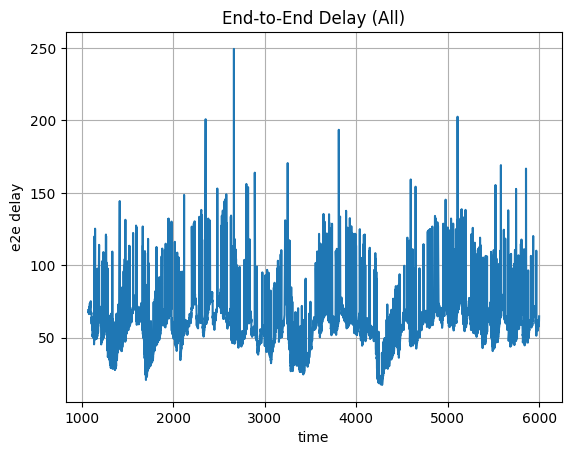

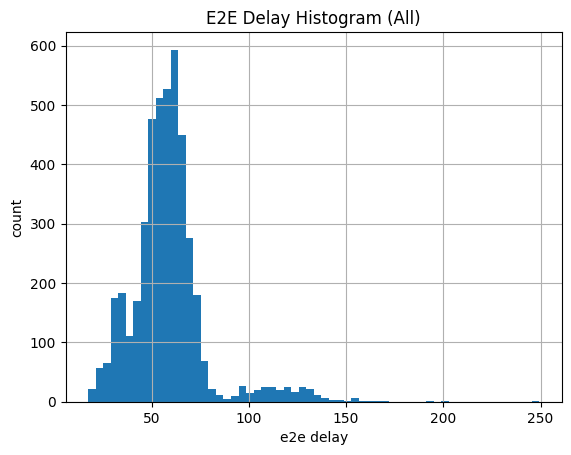

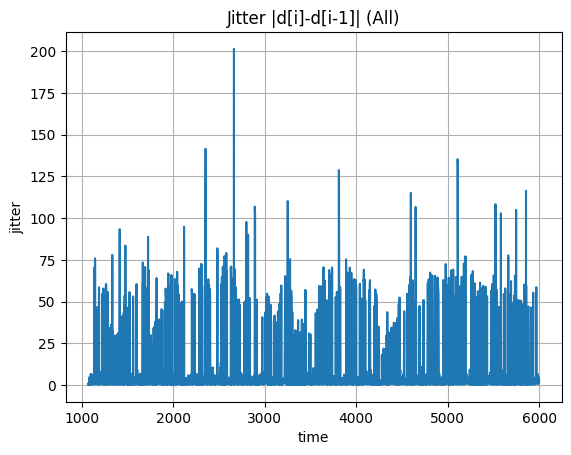

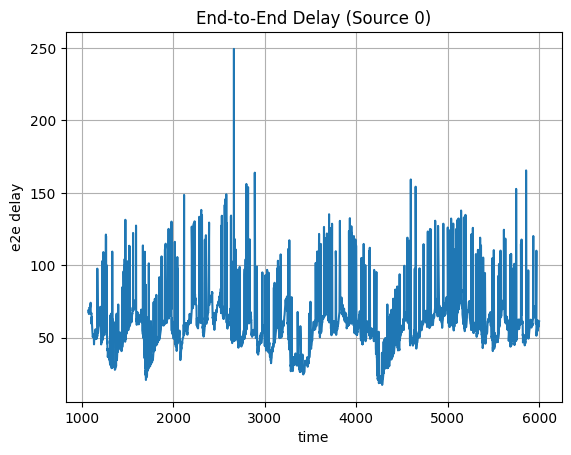

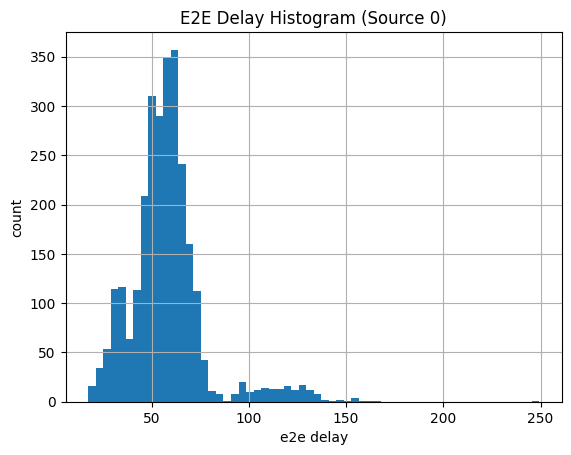

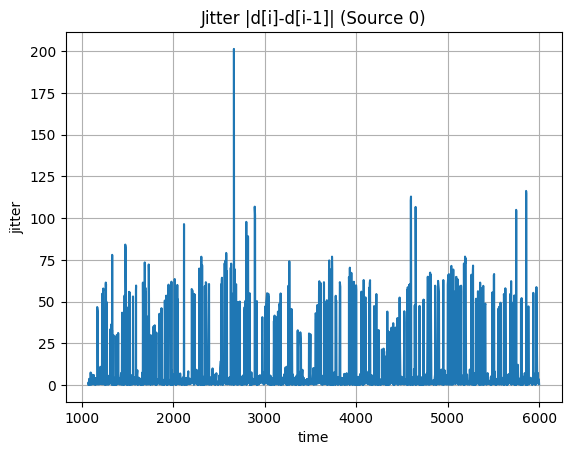

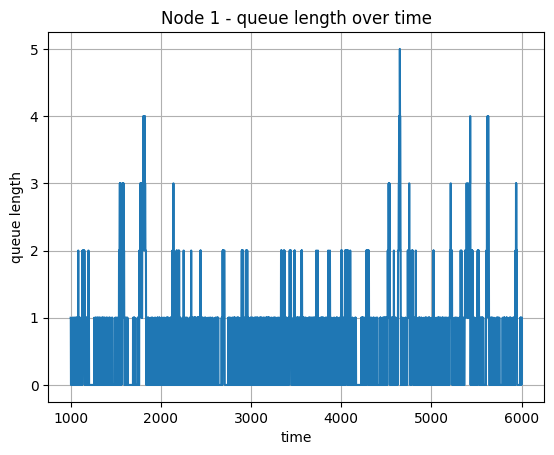

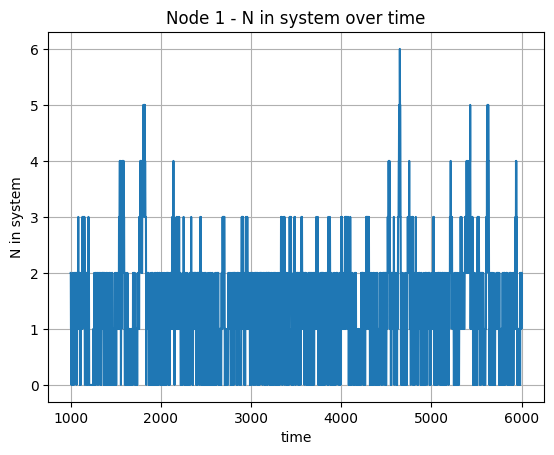

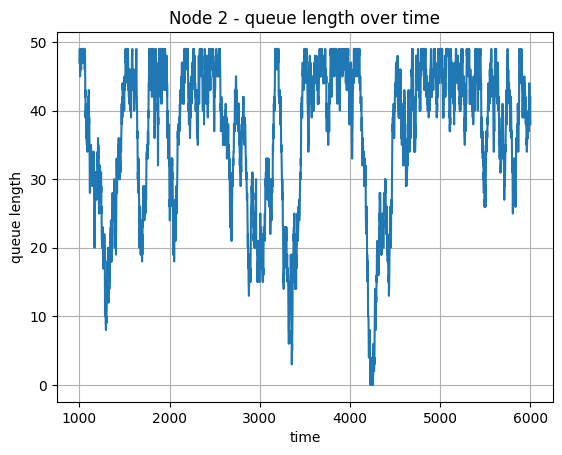

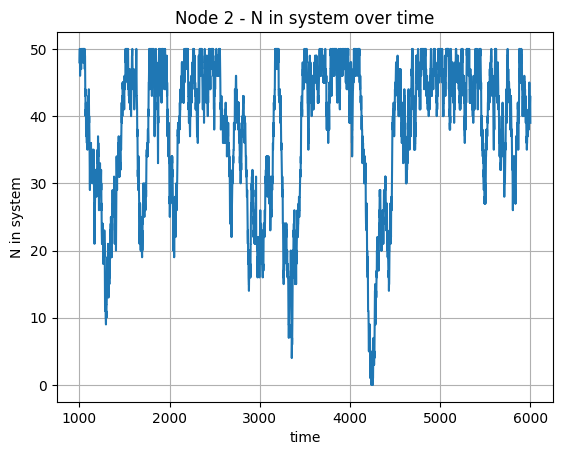

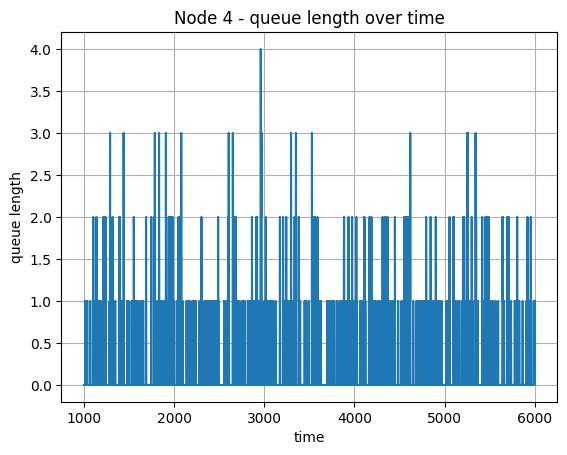

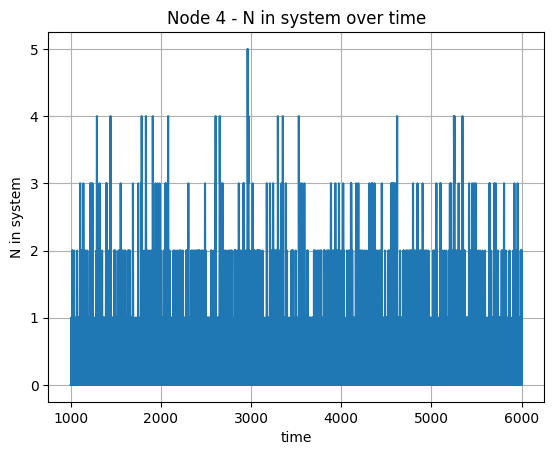

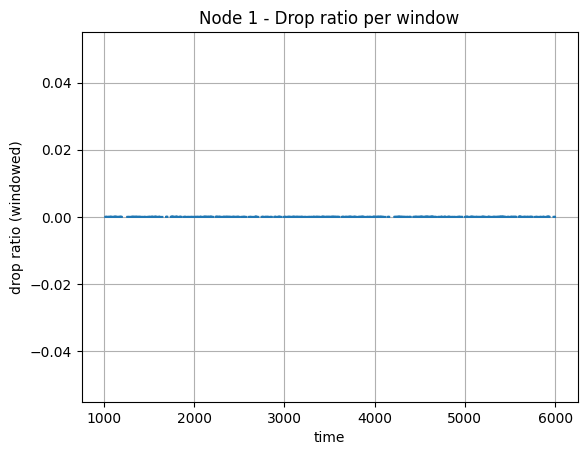

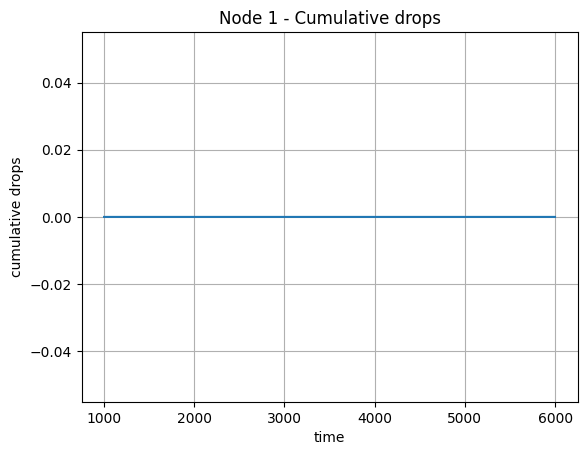

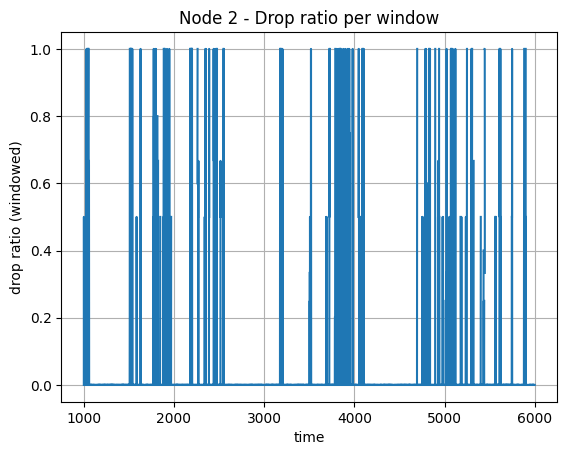

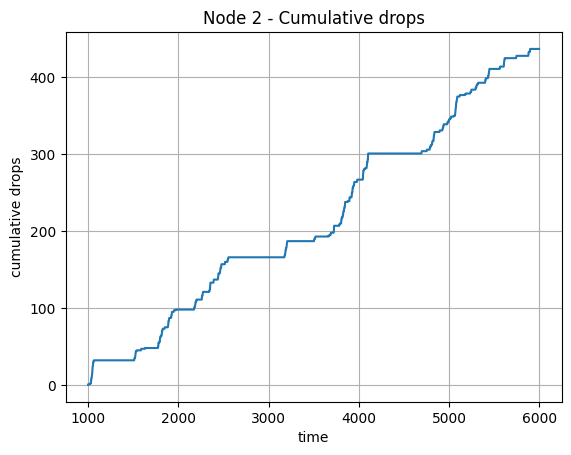

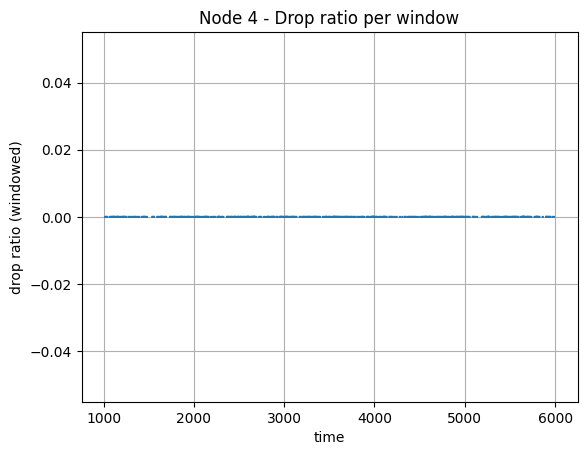

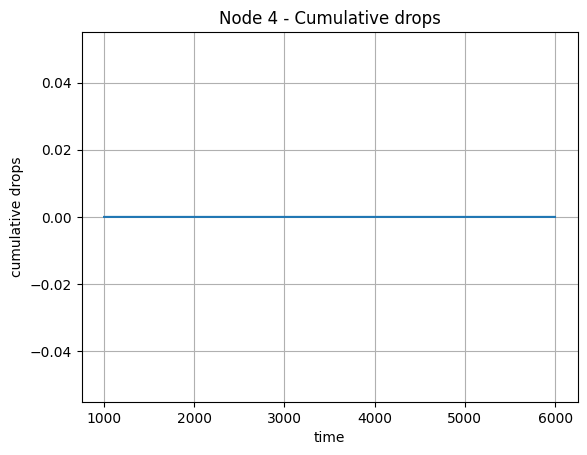

In [ ]:
import matplotlib.pyplot as plt

def _window_ratio(num_series, den_series):
    # ratio of delta num / delta den per sample step
    out = [float("nan")]
    for i in range(1, len(num_series)):
        dn = num_series[i] - num_series[i-1]
        dd = den_series[i] - den_series[i-1]
        out.append(dn / dd if dd > 0 else float("nan"))
    return out

def plot_e2e_timeseries(rep, source_id=None):
    tr = rep.get("trace", None)
    if not tr:
        print("No trace found. Enable tracing before run().")
        return

    if source_id is None:
        t = tr["comp_t"]
        d = tr["comp_e2e"]
        title = "End-to-End Delay (All)"
    else:
        pairs = tr["comp_by_src"].get(source_id, [])
        t = [x[0] for x in pairs]
        d = [x[1] for x in pairs]
        title = f"End-to-End Delay (Source {source_id})"

    plt.figure()
    plt.plot(t, d)
    plt.xlabel("time")
    plt.ylabel("e2e delay")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_e2e_hist(rep, source_id=None, bins=60):
    tr = rep.get("trace", None)
    if not tr:
        print("No trace found. Enable tracing before run().")
        return

    if source_id is None:
        d = tr["comp_e2e"]
        title = "E2E Delay Histogram (All)"
    else:
        pairs = tr["comp_by_src"].get(source_id, [])
        d = [x[1] for x in pairs]
        title = f"E2E Delay Histogram (Source {source_id})"

    plt.figure()
    plt.hist(d, bins=bins)
    plt.xlabel("e2e delay")
    plt.ylabel("count")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_jitter(rep, source_id=None):
    tr = rep.get("trace", None)
    if not tr:
        print("No trace found. Enable tracing before run().")
        return

    if source_id is None:
        t = tr["comp_t"]
        d = tr["comp_e2e"]
        title = "Jitter |d[i]-d[i-1]| (All)"
    else:
        pairs = tr["comp_by_src"].get(source_id, [])
        t = [x[0] for x in pairs]
        d = [x[1] for x in pairs]
        title = f"Jitter |d[i]-d[i-1]| (Source {source_id})"

    if len(d) < 2:
        print("Not enough completions to compute jitter.")
        return

    jt = t[1:]
    jitter = [abs(d[i] - d[i-1]) for i in range(1, len(d))]

    plt.figure()
    plt.plot(jt, jitter)
    plt.xlabel("time")
    plt.ylabel("jitter")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_queue_size(rep, node_id: int, use_nsys=False):
    tr = rep.get("trace", None)
    if not tr:
        print("No trace found. Enable tracing before run().")
        return

    t = tr["t"]
    series = tr["nsys"][node_id] if use_nsys else tr["q"][node_id]
    ylab = "N in system" if use_nsys else "queue length"
    title = f"Node {node_id} - {ylab} over time"

    plt.figure()
    plt.plot(t, series)
    plt.xlabel("time")
    plt.ylabel(ylab)
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_drop_ratio(rep, node_id: int):
    tr = rep.get("trace", None)
    if not tr:
        print("No trace found. Enable tracing before run().")
        return

    t = tr["t"]
    drop = tr["drop"][node_id]
    arr = tr["arr"][node_id]
    ratio = _window_ratio(drop, arr)  # per-sample window drop/arr

    plt.figure()
    plt.plot(t, ratio)
    plt.xlabel("time")
    plt.ylabel("drop ratio (windowed)")
    plt.title(f"Node {node_id} - Drop ratio per window")
    plt.grid(True)
    plt.show()

def plot_drop_cumulative(rep, node_id: int):
    tr = rep.get("trace", None)
    if not tr:
        print("No trace found. Enable tracing before run().")
        return

    t = tr["t"]
    drop = tr["drop"][node_id]

    plt.figure()
    plt.plot(t, drop)
    plt.xlabel("time")
    plt.ylabel("cumulative drops")
    plt.title(f"Node {node_id} - Cumulative drops")
    plt.grid(True)
    plt.show()

def plot_all(rep, queue_nodes, drop_nodes, sources_to_plot=None):
    # E2E + jitter
    plot_e2e_timeseries(rep, source_id=None)
    plot_e2e_hist(rep, source_id=None)
    plot_jitter(rep, source_id=None)

    if sources_to_plot:
        for sid in sources_to_plot:
            plot_e2e_timeseries(rep, source_id=sid)
            plot_e2e_hist(rep, source_id=sid)
            plot_jitter(rep, source_id=sid)

    # queue sizes
    for nid in queue_nodes:
        plot_queue_size(rep, nid, use_nsys=False)
        plot_queue_size(rep, nid, use_nsys=True)

    # drop
    for nid in drop_nodes:
        plot_drop_ratio(rep, nid)
        plot_drop_cumulative(rep, nid)

plot_all(rep, queue_nodes=[1,2,4], drop_nodes=[1,2,4], sources_to_plot=[0])
